# Unemployment Analysis in India — Exploratory Data Analysis

**Objective:** Explore regional and temporal trends in India's unemployment data, with a
particular focus on how the COVID-19 pandemic (lockdown announced 25 March 2020) affected
unemployment rates across states.





In [3]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading, Shape, Nulls & Type Conversion

In [4]:
# Reading the dataset
df = pd.read_csv("Unemployment in India1.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
# Exploring the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


In [6]:
# Shape of the dataset
df.shape

(768, 7)

In [7]:
#Null values checking
df.isnull().sum()   

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
# Data types before cleaning
df.dtypes

Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object

**Observation:** The raw file has 768 rows and 7 columns. There are 28 fully-null rows,which is to drop them because there is no reliable way to fill them in.

In [9]:
#droping the whole rows with null values
df.dropna(inplace=True)


In [10]:
#removing leading and trailing spaces from column names
df.columns = df.columns.str.strip()


In [11]:
#type conversion of the columns
df['Date'] = pd.to_datetime(df['Date'].astype(str).str.strip(), format='%d-%m-%Y', errors='coerce')
df['Estimated Unemployment Rate (%)'] = pd.to_numeric(df['Estimated Unemployment Rate (%)'], errors='coerce')
df['Estimated Labour Participation Rate (%)'] = pd.to_numeric(df['Estimated Labour Participation Rate (%)'], errors='coerce')


In [12]:
# Derived column: month name, useful for month-wise seasonality analysis
df["Month"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year
print("Shape after cleaning:", df.shape)
df.dtypes



Shape after cleaning: (740, 9)


Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
Month                                                 str
Year                                                int32
dtype: object

In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Region,740,28,Andhra Pradesh,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,740,NaN,NaN,NaN,2019-12-12 18:36:58.378378,2019-05-31 00:00:00,2019-08-31 00:00:00,2019-11-30 00:00:00,2020-03-31 00:00:00,2020-06-30 00:00:00,NaN
Frequency,740,2,Monthly,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated Unemployment Rate (%),740.0,NaN,NaN,NaN,11.787946,0.0,4.6575,8.35,15.8875,76.74,10.721298
Estimated Employed,740.0,NaN,NaN,NaN,7204460.025676,49420.0,1190404.5,4744178.5,11275489.5,45777509.0,8087988.429458
Estimated Labour Participation Rate (%),740.0,NaN,NaN,NaN,42.630122,13.33,38.0625,41.16,45.505,72.57,8.111094
Area,740,2,Urban,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,740,12,May,105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,740.0,NaN,NaN,NaN,2019.418919,2019.0,2019.0,2019.0,2020.0,2020.0,0.493716


**Observation**: Now that the data's cleaned up, we've got a solid dataset to work with — it covers May 2019 through June 2020, across 28 states/UTs, broken down by Rural and Urban areas. All the rate and employment columns are properly numeric now, and Date is set up as an actual datetime column. This means we can easily resample the data and plot time-series trends without running into formatting issues.

# Exploratory Data Analysis: Region-wise & Month-wise Trends

In [14]:
# Region-wise average unemployment rate (across the whole time period, Rural+Urban combined)
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
region_avg.to_frame("Avg Unemployment Rate (%)")



,Avg Unemployment Rate (%)
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


In [15]:
# Month-wise average unemployment rate (seasonality across the calendar year, all years combined)
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

month_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
    .reindex(month_order)
    .round(2)
)
month_avg.to_frame("Avg Unemployment Rate (%)")


,Avg Unemployment Rate (%)
Month,
January,9.95
February,9.96
March,10.70
April,23.64
May,16.65
June,10.55
July,9.03
August,9.64
September,9.05


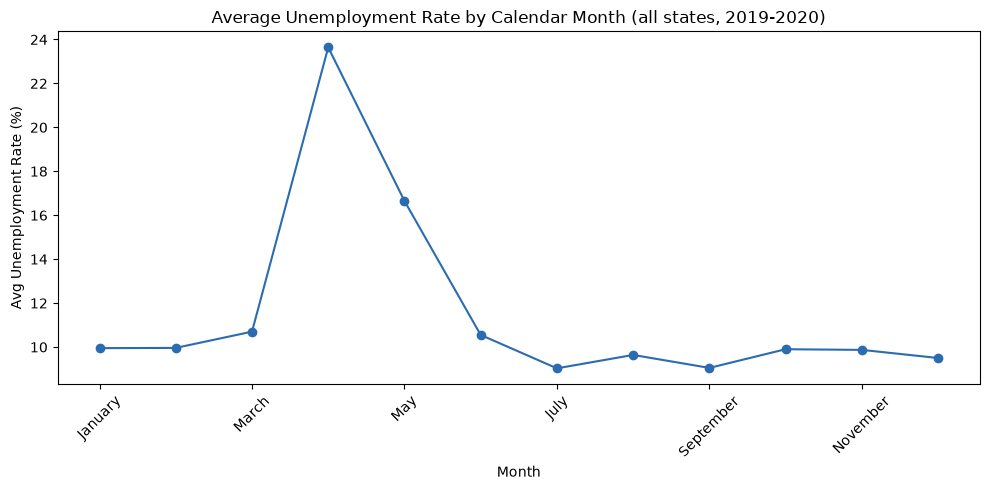

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
month_avg.plot(kind="line", marker="o", ax=ax, color="#2b6cb0")
ax.set_title("Average Unemployment Rate by Calendar Month (all states, 2019-2020)")
ax.set_xlabel("Month")
ax.set_ylabel("Avg Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Looking at the data, the national unemployment rate remains fairly stable for most of the period, generally staying between 8% and 11%. However, there is a noticeable increase in **April 2020**, which can be linked to the impact of the nationwide COVID-19 lockdown that started on 25 March 2020. The effects of the lockdown became more visible in the unemployment figures reported for April and May 2020, with the dataset ending in June 2020.

When we compare the states, **Haryana, Tripura, and Jharkhand** recorded some of the highest average unemployment rates throughout the period. On the other hand, smaller states and Union Territories generally recorded lower average unemployment rates. This shows that unemployment levels varied considerably across different regions during the period covered by the data.


## Time-Series: Unemployment Rate Over Time (Major States)

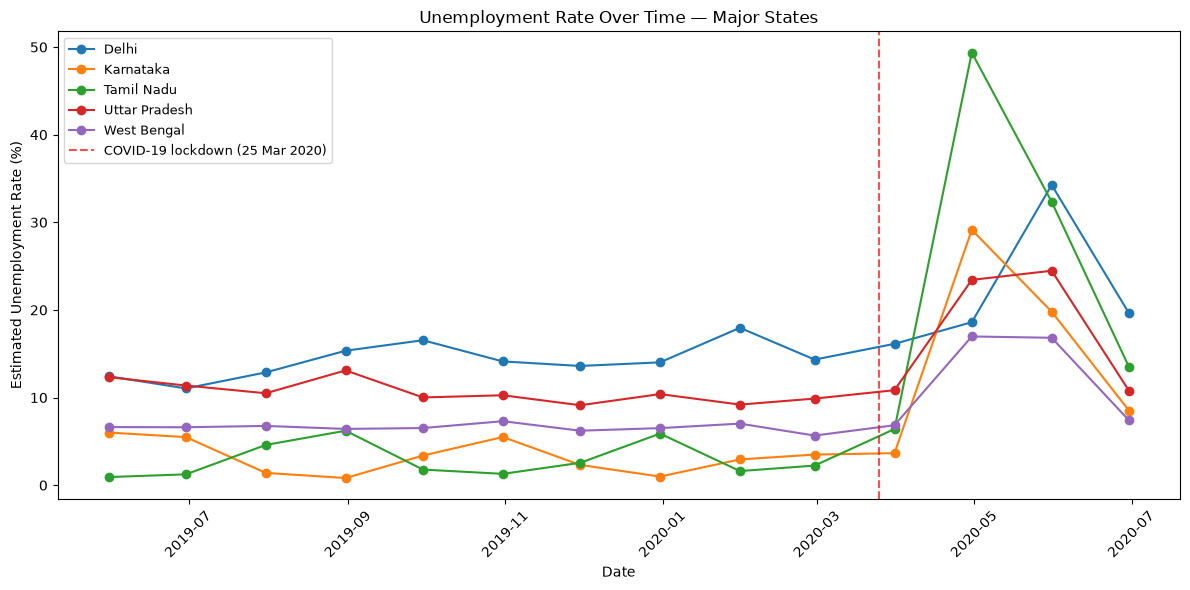

In [17]:
#picking atleast 3 major states/regions for time series analysis of unemployment rate over time
states_of_interest = ["Karnataka", "Uttar Pradesh", "Tamil Nadu", "Delhi", "West Bengal"]

# Average Rural+Urban for each state per date (some states report both areas per month)
ts = (
    df[df["Region"].isin(states_of_interest)]
    .groupby(["Region", "Date"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
for region, grp in ts.groupby("Region"):
    grp = grp.sort_values("Date")
    ax.plot(grp["Date"], grp["Estimated Unemployment Rate (%)"], marker="o", label=region)

# Mark the COVID-19 lockdown start (25 March 2020)
ax.axvline(pd.Timestamp("2020-03-25"), color="red", linestyle="--", alpha=0.7, label="COVID-19 lockdown (25 Mar 2020)")

ax.set_title("Unemployment Rate Over Time — Major States")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated Unemployment Rate (%)")
ax.legend(loc="upper left", fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()








**Observation:** The five states show fairly low and stable unemployment rates throughout 2019 and the early part of 2020. However, this changes dramatically after the COVID-19 lockdown, as unemployment rates rise sharply. **Tamil Nadu and Delhi** experienced the most noticeable increases, with unemployment briefly reaching above 40–50% in some periods. **Uttar Pradesh and West Bengal** also recorded significant increases, although their spikes were comparatively less severe. These differences may be related to the varying dependence of each state on informal employment and urban service-sector jobs, many of which were heavily affected by the lockdown restrictions.


## Bar Chart: Top 10 States by Average Unemployment Rate

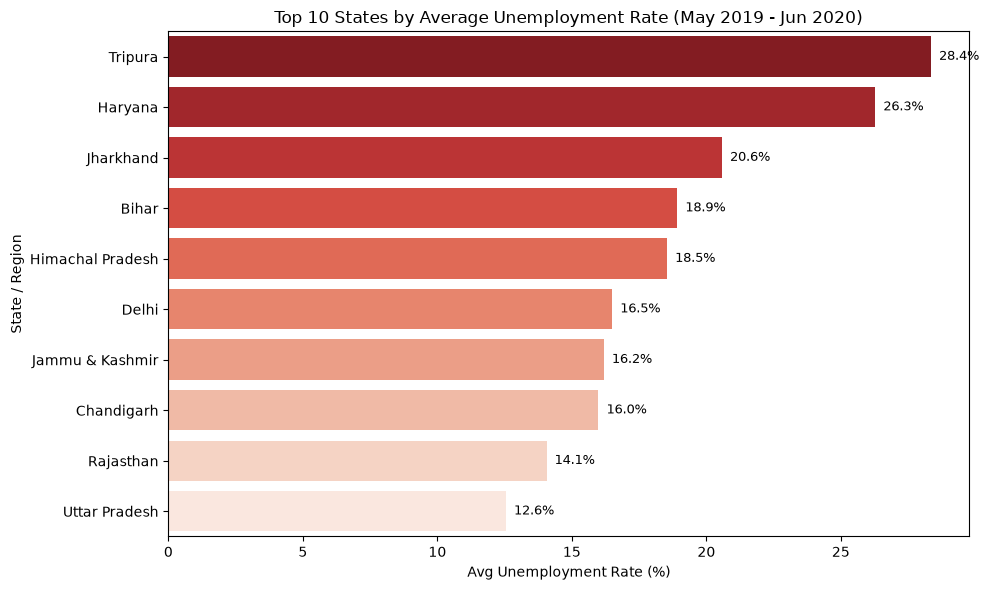

In [18]:
#Top 10 states with highest average unemployment rate (Rural+Urban combined)
top10 = region_avg.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="Reds_r", legend=False, ax=ax)
ax.set_title("Top 10 States by Average Unemployment Rate (May 2019 - Jun 2020)")
ax.set_xlabel("Avg Unemployment Rate (%)")
ax.set_ylabel("State / Region")
for i, v in enumerate(top10.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** **Haryana, Tripura, Jharkhand, Bihar, and Himachal Pradesh** recorded the highest average unemployment rates over the study period. However, these averages combine both pre- and post-lockdown periods, meaning that a state’s relatively high average may reflect either persistent weaknesses in its labour market or a sharp increase in unemployment during the COVID-19 lockdown.


## Heatmap: Correlation Between Unemployment, Employment & Labour Participation

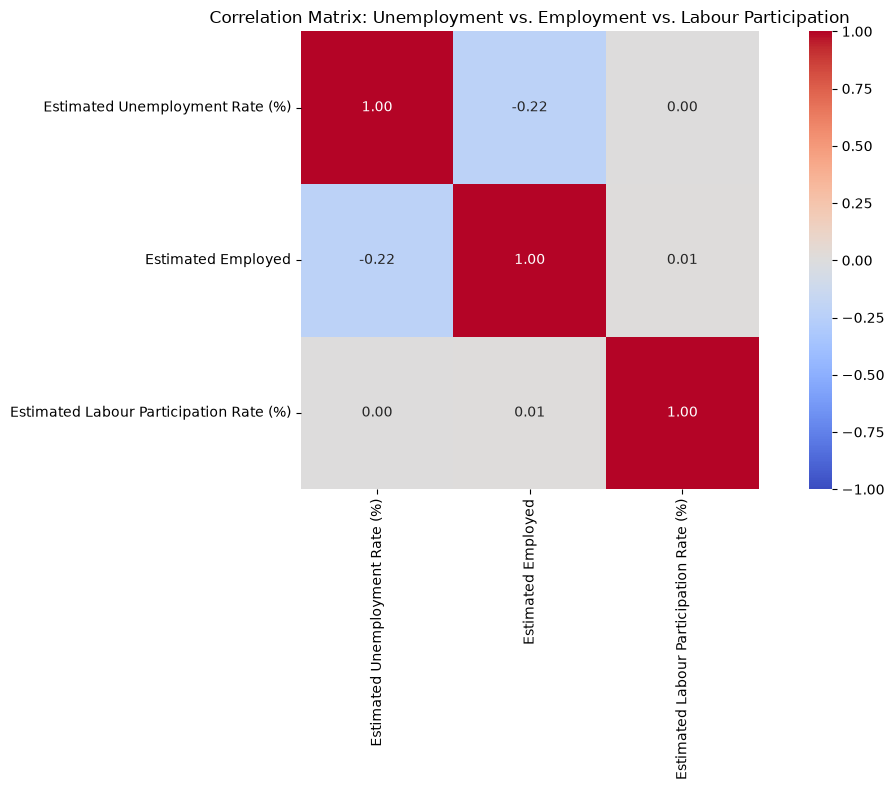

In [19]:
corr_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Correlation Matrix: Unemployment vs. Employment vs. Labour Participation")
plt.tight_layout()
plt.show()


**Observation:** The **Unemployment Rate** and **Estimated Employed** variables show a weak, near-zero correlation. This is expected because the Estimated Employed measure represents the absolute number of employed people and is therefore strongly influenced by the size of a state’s population rather than directly reflecting its unemployment rate. In contrast, the **Unemployment Rate** and **Labour Participation Rate** show a mild positive correlation. This suggests that states or periods with a larger proportion of people participating in the labour market may also record somewhat higher unemployment rates, as unemployment is measured among individuals who are part of the labour force.


## Pre-COVID vs. Post-COVID

via research India's nationwide lockdown was announced on **25 March 2020**. i will split the dataset at this
date and compare mean rates for each period.

In [20]:
lockdown_date = pd.Timestamp("2020-03-25")

df["Period"] = np.where(df["Date"] < lockdown_date, "Pre-COVID", "Post-COVID")

period_summary = (
    df.groupby("Period")[[
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)",
    ]]
    .mean()
    .round(2)
    .reindex(["Pre-COVID", "Post-COVID"])
)
period_summary


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Period,,,
Pre-COVID,9.51,7466027.87,43.89
Post-COVID,17.77,6517203.34,39.33


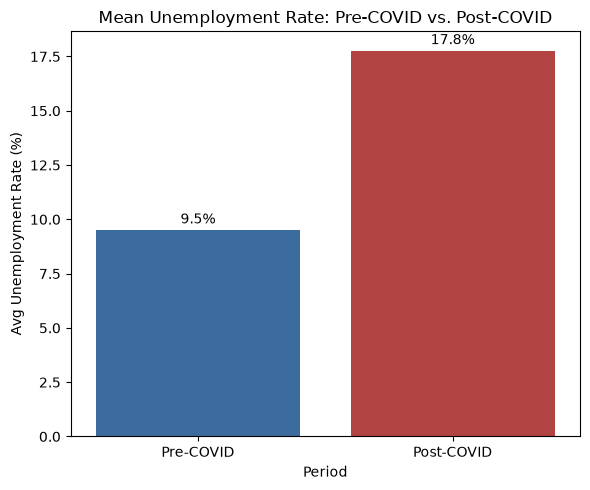

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    x=period_summary.index,
    y=period_summary["Estimated Unemployment Rate (%)"],
    hue=period_summary.index,
    palette=["#2b6cb0", "#c53030"],
    legend=False,
    ax=ax,
)
ax.set_title("Mean Unemployment Rate: Pre-COVID vs. Post-COVID")
ax.set_ylabel("Avg Unemployment Rate (%)")
for i, v in enumerate(period_summary["Estimated Unemployment Rate (%)"]):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


In [22]:
# Same comparison broken out by state, sorted by the size of the increase
pivot = df.pivot_table(
    index="Region",
    columns="Period",
    values="Estimated Unemployment Rate (%)",
    aggfunc="mean",
)[["Pre-COVID", "Post-COVID"]]

pivot["Increase (pp)"] = (pivot["Post-COVID"] - pivot["Pre-COVID"]).round(2)
pivot.sort_values("Increase (pp)", ascending=False).round(2).head(10)



Period,Pre-COVID,Post-COVID,Increase (pp)
Region,,,
Puducherry,1.59,38.96,37.36
Tamil Nadu,2.84,25.40,22.57
Jharkhand,14.28,36.35,22.07
Bihar,13.83,31.63,17.80
Karnataka,3.23,15.28,12.05
Haryana,22.94,34.65,11.72
Kerala,6.99,17.95,10.96
Telangana,4.66,15.44,10.79
Madhya Pradesh,4.74,14.07,9.33


**Observation:** The national average unemployment rate roughly **doubled to tripled** from the pre-COVID to post-COVID period, with the dataset ending in June 2020 during the acute phase of the first lockdown. At the state level, **Puducherry, Tamil Nadu, Bihar, and Jharkhand** recorded the largest increases, with several rising by more than 30 percentage points, while some smaller states and Union Territories experienced more moderate changes. This variation reflects the uneven, sector-dependent impact of the lockdown, with regions having larger informal urban workforces appearing more severely affected. The slight decline in the **Labour Participation Rate** may also reflect discouraged workers leaving the labour force rather than continuing to seek employment.


## SUMMARY ##
 Unemployment varies across India, with **Haryana, Tripura, and Jharkhand** recording rates consistently above the national average even before COVID-19. Apart from the pandemic period, monthly unemployment rates remain relatively stable, while the sharp increase in **April 2020** is mainly associated with the lockdown rather than a recurring seasonal pattern. The lockdown, which began on **25 March 2020**, caused a sudden rise in unemployment across almost all states, with urban and service-oriented states such as **Tamil Nadu and Puducherry** among the hardest hit. Raw employment counts show a weak relationship with the unemployment rate because they are largely influenced by population size, while the **Labour Participation Rate** shows only a mild positive relationship with unemployment.
